# Module 3 — Intent Classifier (Routing)

**Goal:** route each message to the correct handling path using the customer's intent.

**Data:** [bitext/Bitext-customer-support-llm-chatbot-training-dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset)
— 26,872 instruction/response pairs. The `intent` column is gold-labelled, so this is a **supervised
classification** task (no zero/few-shot needed).

**Method:** the 27 fine-grained intents are condensed into the **5 routing categories present in the
data** (greeting & out-of-scope are handled at runtime — see below):
- `order_status`, `order_management`, `billing_and_refunds`, `account_management`, `complaint`.

TF-IDF (word unigrams+bigrams) → linear logistic regression, trained on a stratified 80/20 split.

**Runtime additions (covered in `src/models/intent.py`):**
- **Small-talk routing** (`greeting` / `thank-you` / `goodbye`) via a lightweight pattern matcher —
  Bitext contains no greetings, so we detect these explicitly (incl. common languages).
- **Relevance gate** → low-confidence predictions on non-support text become `out_of_scope`
  (e.g. *"what is the meaning of life"* → honest "can't help" + escalate) instead of a hallucinated answer.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import joblib
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from src.config import INTENT_TO_CATEGORY, INTENT_DIR
from src.preprocessing import normalize_text
import warnings
warnings.filterwarnings('ignore')

In [2]:
ds = load_dataset('bitext/Bitext-customer-support-llm-chatbot-training-dataset')
df = ds['train'].to_pandas()[['instruction', 'intent']].copy()
df['category'] = df['intent'].map(INTENT_TO_CATEGORY)
assert df['category'].notna().all(), sorted(df.loc[df['category'].isna(), 'intent'].unique())
df['category'] = df['category'].astype(str)
df['clean'] = df['instruction'].apply(lambda x: normalize_text(x))
mapping = pd.DataFrame(sorted(INTENT_TO_CATEGORY.items()), columns=['fine_intent', 'routing_category'])
print('\nMapping table (fine-grained -> routing category):')
with pd.option_context('display.max_rows', 40):
    display_none = None
table = mapping.groupby('routing_category')['fine_intent'].apply(lambda s: ', '.join(sorted(s)))
for cat, ints in table.items(): print(f'  {cat:18s} <- {ints}')
print('\nCategory distribution:', dict(df['category'].value_counts()))


Mapping table (fine-grained -> routing category):
  account_management <- change_shipping_address, create_account, delete_account, edit_account, newsletter_subscription, recover_password, registration_problems, set_up_shipping_address, switch_account
  billing_and_refunds <- cancel_subscription, change_subscription, check_cancellation_fee, check_invoice, check_payment_methods, check_refund_policy, get_invoice, get_refund, payment_issue, payment_methods, refund_not_received, track_refund
  complaint          <- complaint, contact_human_agent, customer_service, review
  greeting           <- appreciation, goodbye, greeting, thank_you
  order_management   <- cancel_order, change_order, place_order
  order_status       <- contact_customer_service, delivery_options, delivery_period, track_order
  out_of_scope       <- out_of_scope

Category distribution: {'account_management': 8955, 'billing_and_refunds': 7939, 'order_status': 3989, 'complaint': 2996, 'order_management': 2993}


In [3]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['category'])
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, max_features=120_000)
X_train = vectorizer.fit_transform(train_df['clean']); X_test = vectorizer.transform(test_df['clean'])
y_train, y_test = train_df['category'], test_df['category']
model = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs')
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(f'\nAccuracy = {accuracy_score(y_test, preds):.4f}')
print(classification_report(y_test, preds, zero_division=0))


Accuracy = 0.9980
                     precision    recall  f1-score   support

 account_management       1.00      1.00      1.00      1791
billing_and_refunds       1.00      1.00      1.00      1588
          complaint       0.99      1.00      1.00       599
   order_management       0.99      1.00      1.00       599
       order_status       1.00      0.99      0.99       798

           accuracy                           1.00      5375
          macro avg       1.00      1.00      1.00      5375
       weighted avg       1.00      1.00      1.00      5375



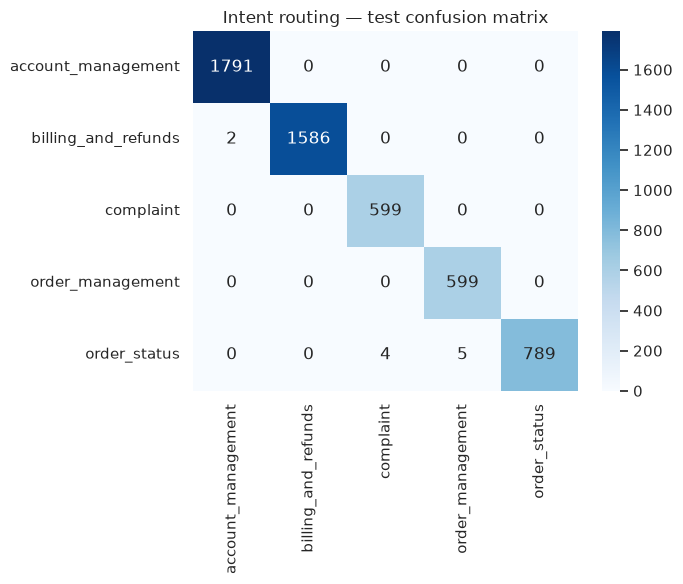

In [4]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
cm = confusion_matrix(y_test, preds, labels=model.classes_)
plt.figure(figsize=(7, 6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Intent routing — test confusion matrix'); plt.tight_layout(); plt.show()

In [5]:
joblib.dump(vectorizer, INTENT_DIR / 'vectorizer.joblib')
joblib.dump(model, INTENT_DIR / 'model.joblib')
joblib.dump({'classes': list(model.classes_)}, INTENT_DIR / 'meta.joblib')
from src.models.intent import IntentClassifier
ic = IntentClassifier()
for q in ["hello there", "where is my order", "I want a refund for the shoes I returned",
          "how do I change my password", "I would like to place a new order",
          "I want to complain about the delivery service", "what is the meaning of life"]:
    r = ic.predict(q)
    print(f'{{r["category"]:18s}} (conf={{r["confidence"]:.2f}}, src={{r["source"]}})  {q}')
print('\nArtifacts saved to', INTENT_DIR)

{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  hello there
{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  where is my order
{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  I want a refund for the shoes I returned
{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  how do I change my password
{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  I would like to place a new order
{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  I want to complain about the delivery service
{r["category"]:18s} (conf={r["confidence"]:.2f}, src={r["source"]})  what is the meaning of life

Artifacts saved to /media/mosaab/01DC3BA86FD6B9C0/Projects/ITI/NLP/project/artifacts/intent
